# 深度可分离卷积和常规卷积比较实验

In [41]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# define metadata
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
batch_size = 64
epoch = 40

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = datasets.CIFAR10(root="./data", download=True, train=True, transform=transforms)
test_data = datasets.CIFAR10(root="./data", download=True, train=False, transform=transforms)

train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, num_workers=2, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, num_workers=2, shuffle=False)

class CNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels=32, kernel_size=3, padding=1, bias=False),  # [64, 3, 32, 32] -> [64, 32, 32, 32],
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # [64, 32, 32, 32] -> [64, 32, 16, 16]

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=False), # [64, 32, 16, 16] -> [64, 64, 16, 16]
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # [64, 64, 16, 16] -> [64, 64, 8, 8]

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, bias=False),  # [64, 64, 8, 8] -> [64, 128, 8, 8]
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # [64, 128, 8, 8] -> [64, 128, 4, 4]
        )
        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)


    def forward(self, x):
        out = self.conv(x)
        out = self.avg_pool(out)
        out = out.view(x.size(0), -1)
        out = self.fc(out)
        return out


class DepthwiseCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels=32, kernel_size=3, padding=1, bias=False),  # [64, 3, 32, 32] -> [64, 32, 32, 32],
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  #  -> [64, 32, 16, 16]

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, groups=32, bias=False), #  -> [64, 32, 16, 16]
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1, padding=0, bias=False), # -> [64, 64, 16, 16]
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # [64, 64, 16, 16] -> [64, 64, 8, 8]

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, groups=64, bias=False),  # [64, 64, 8, 8]
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1, padding=0, bias=False), # [64, 128, 8, 8]
            nn.BatchNorm2d(128),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(2),  # [64, 256, 8, 8] -> [64, 128, 4, 4]
        )
        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)


    def forward(self, x):
        out = self.conv(x)
        out = self.avg_pool(out)
        out = out.view(x.size(0), -1)
        out = self.fc(out)
        return out


def count_parameters(model, trainable=True):
    if trainable:
        params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        params = sum(p.numel() for p in model.parameters())
    return params

Using device: cuda


In [45]:
def train_model(model: CNN, epochs= 10, train_dataloader = train_dataloader, test_dataloader = test_dataloader):
    loss_hist = []
    val_acc_hist = []
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        in_epoch_loss = 0.0
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)

            loss = criterion(y_hat, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            in_epoch_loss += loss.item()

        train_loss = in_epoch_loss / len(train_dataloader)

        total = 0
        correct = 0

        model.eval()
        with torch.no_grad():
            for x, y in test_dataloader:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)
                _, predicted = torch.max(y_hat.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        accuracy = 100 * correct / total

        loss_hist.append(train_loss)
        val_acc_hist.append(accuracy)
        print(f"[Epoch {epoch + 1}/{epochs}] Training Loss {train_loss:.4f} | Test Set Validation Acc: {accuracy:.4f}")

    return loss_hist, val_acc_hist

In [50]:
cnn = CNN().to(device)
print(f"model size {count_parameters(cnn)}")
cnn_loss_hist, cnn_val_acc_hist = train_model(cnn, epochs = 40)

model size 94762
[Epoch 1/40] Training Loss 1.3631 | Test Set Validation Acc: 56.4600
[Epoch 2/40] Training Loss 1.0747 | Test Set Validation Acc: 59.2200
[Epoch 3/40] Training Loss 0.9474 | Test Set Validation Acc: 65.0700
[Epoch 4/40] Training Loss 0.8651 | Test Set Validation Acc: 62.2100
[Epoch 5/40] Training Loss 0.7934 | Test Set Validation Acc: 70.5600
[Epoch 6/40] Training Loss 0.7392 | Test Set Validation Acc: 70.5500
[Epoch 7/40] Training Loss 0.6951 | Test Set Validation Acc: 68.1600
[Epoch 8/40] Training Loss 0.6505 | Test Set Validation Acc: 72.5500
[Epoch 9/40] Training Loss 0.6151 | Test Set Validation Acc: 74.3900
[Epoch 10/40] Training Loss 0.5793 | Test Set Validation Acc: 74.2100
[Epoch 11/40] Training Loss 0.5511 | Test Set Validation Acc: 72.1100
[Epoch 12/40] Training Loss 0.5207 | Test Set Validation Acc: 76.0700
[Epoch 13/40] Training Loss 0.4954 | Test Set Validation Acc: 75.1300
[Epoch 14/40] Training Loss 0.4684 | Test Set Validation Acc: 76.4600
[Epoch 15/40

In [51]:
depthwise_cnn = DepthwiseCNN().to(device)
print(f"model size {count_parameters(depthwise_cnn)}")
dcnn_loss_hist, dcnn_val_acc_hist = train_model(depthwise_cnn, epochs=40)

model size 13898
[Epoch 1/40] Training Loss 1.4882 | Test Set Validation Acc: 55.5600
[Epoch 2/40] Training Loss 1.1846 | Test Set Validation Acc: 59.6400
[Epoch 3/40] Training Loss 1.0905 | Test Set Validation Acc: 61.8700
[Epoch 4/40] Training Loss 1.0277 | Test Set Validation Acc: 63.5200
[Epoch 5/40] Training Loss 0.9834 | Test Set Validation Acc: 65.1400
[Epoch 6/40] Training Loss 0.9465 | Test Set Validation Acc: 66.1100
[Epoch 7/40] Training Loss 0.9113 | Test Set Validation Acc: 66.5600
[Epoch 8/40] Training Loss 0.8873 | Test Set Validation Acc: 66.9800
[Epoch 9/40] Training Loss 0.8642 | Test Set Validation Acc: 68.2300
[Epoch 10/40] Training Loss 0.8443 | Test Set Validation Acc: 68.6300
[Epoch 11/40] Training Loss 0.8275 | Test Set Validation Acc: 69.6100
[Epoch 12/40] Training Loss 0.8106 | Test Set Validation Acc: 69.5800
[Epoch 13/40] Training Loss 0.7977 | Test Set Validation Acc: 70.1300
[Epoch 14/40] Training Loss 0.7794 | Test Set Validation Acc: 69.9900
[Epoch 15/40

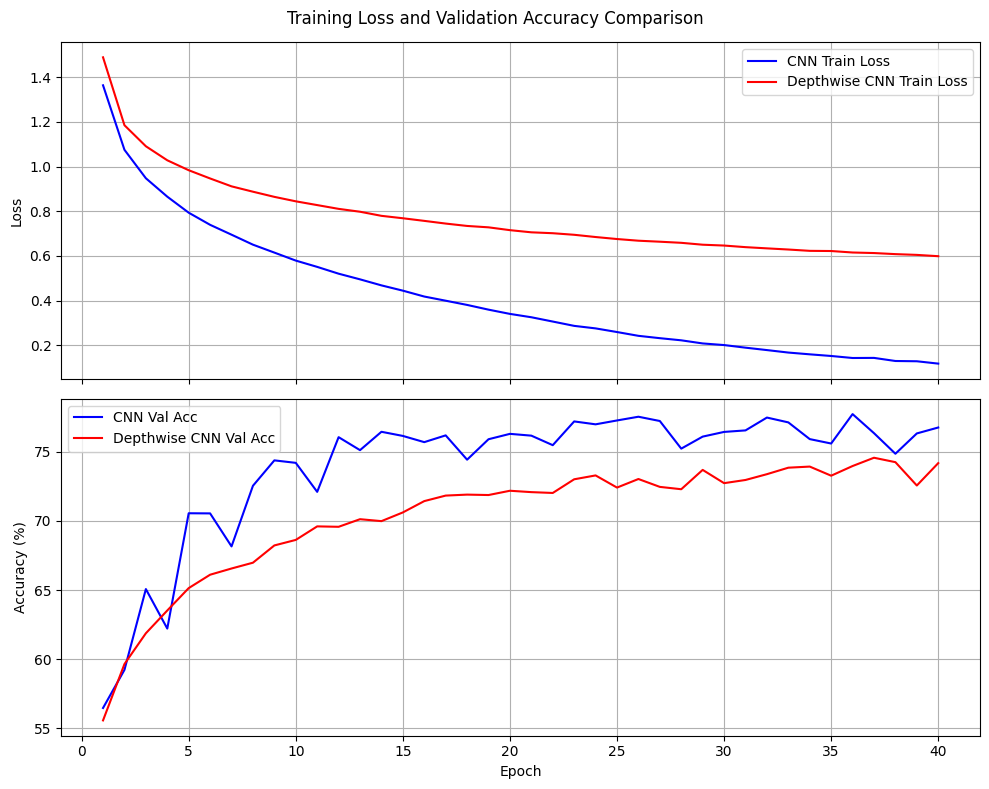

In [52]:
import matplotlib.pyplot as plt

epochs = range(1, len(cnn_loss_hist) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(epochs, cnn_loss_hist, 'b-', label='CNN Train Loss')
ax1.plot(epochs, dcnn_loss_hist, 'r-', label='Depthwise CNN Train Loss')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, cnn_val_acc_hist, 'b-', label='CNN Val Acc')
ax2.plot(epochs, dcnn_val_acc_hist, 'r-', label='Depthwise CNN Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training Loss and Validation Accuracy Comparison')
plt.tight_layout()
plt.show()